# 09. Adversarial v2 Evaluation

**Цель:** Оценить устойчивость детекторов к трём типам adversarial-атак (v2):
1. **synonym** — замена ~15% слов по словарю синонимов
2. **back_translation** — Ru → En → Ru через Helsinki-NLP MarianMT
3. **homoglyph** — замена ~7% кириллических символов визуально похожими латинскими

**Детекторы:**
- Baseline C (TF-IDF char+word, LogReg C=50)
- Transformer (ruRoBERTa-large, fine-tuned)
- Cascade (TF-IDF → Transformer при uncertainty [0.30, 0.70])

**Базовая линия:** test_tm.jsonl (оригинальные AI-тексты без атак)

**Источник adversarial-текстов:** 200 AI-текстов из test_tm.jsonl (label=1), преобразованных каждым методом.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report,
)
from scipy.sparse import hstack
import joblib

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

SEED = 42
np.random.seed(SEED)

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]


## 1. Загрузка данных

In [2]:
# Baseline: оригинальные AI-тексты из test_tm (те же 200 doc_id, что в adversarial)
test_tm = load_jsonl(PROJECT_ROOT / "data/splits/test_tm.jsonl")
test_ai = [r for r in test_tm if r["label"] == 1]
print(f"test_tm AI texts: {len(test_ai)}")

# Adversarial v2
adv_dir = PROJECT_ROOT / "data/adversarial_v2"
adv_data = {}
for f in sorted(adv_dir.glob("adversarial_*.jsonl")):
    method = f.stem.replace("adversarial_", "")
    adv_data[method] = load_jsonl(f)
    print(f"  {method}: {len(adv_data[method])} texts")

# Adversarial v1 (LLM paraphrase)
adv_v1_dir = PROJECT_ROOT / "data/adversarial"
adv_v1 = {}
for f in sorted(adv_v1_dir.glob("adversarial_*.jsonl")):
    name = f.stem.replace("adversarial_paraphrase_", "paraphrase_")
    adv_v1[name] = load_jsonl(f)
    print(f"  v1 {name}: {len(adv_v1[name])} texts")

# Собираем original_doc_ids из adversarial synonym (все 3 метода v2 используют одни и те же 200)
if "synonym" in adv_data:
    adv_doc_ids = {r["meta"]["original_doc_id"] for r in adv_data["synonym"]}
    baseline_ai = [r for r in test_ai if r["doc_id"] in adv_doc_ids]
    print(f"\nBaseline (matched 200 originals): {len(baseline_ai)}")
else:
    baseline_ai = test_ai[:200]
    print(f"\nBaseline (first 200): {len(baseline_ai)}")

test_tm AI texts: 1411
  back_translation: 200 texts
  homoglyph: 200 texts
  synonym: 200 texts
  v1 paraphrase_GigaChat: 508 texts
  v1 paraphrase_yandexgpt-lite: 8 texts

Baseline (matched 200 originals): 200


## 2. Загрузка моделей

In [3]:
# --- TF-IDF (Baseline C) ---
ARTIFACTS = PROJECT_ROOT / "artifacts/service"
tfidf_char = joblib.load(ARTIFACTS / "tfidf_char_tm.joblib")
tfidf_word = joblib.load(ARTIFACTS / "tfidf_word_tm.joblib")
logreg = joblib.load(ARTIFACTS / "model_C_logreg.joblib")

def tfidf_predict_proba(texts):
    X = hstack([tfidf_char.transform(texts), tfidf_word.transform(texts)])
    return logreg.predict_proba(X)[:, 1]

print(f"TF-IDF loaded: char={tfidf_char.max_features}, word={tfidf_word.max_features}")

# --- Transformer (ruRoBERTa-large) ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = str(PROJECT_ROOT / "artifacts/transformer/model")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
transformer_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
transformer_model.eval()

print(f"Transformer loaded: {sum(p.numel() for p in transformer_model.parameters()) / 1e6:.0f}M params, device={device}")

def transformer_predict_proba(texts, batch_size=16):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                          max_length=512, padding=True).to(device)
        with torch.no_grad():
            logits = transformer_model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
    return np.array(all_probs)

# --- Cascade ---
CASCADE_LO, CASCADE_HI = 0.30, 0.70

def cascade_predict_proba(texts, batch_size=16):
    tfidf_probs = tfidf_predict_proba(texts)
    uncertain = (tfidf_probs >= CASCADE_LO) & (tfidf_probs <= CASCADE_HI)
    uncertain_idx = np.where(uncertain)[0]
    final = tfidf_probs.copy()
    if len(uncertain_idx) > 0:
        unc_texts = [texts[i] for i in uncertain_idx]
        trans_probs = transformer_predict_proba(unc_texts, batch_size)
        for j, idx in enumerate(uncertain_idx):
            final[idx] = trans_probs[j]
    return final

print("Cascade ready.")

TF-IDF loaded: char=30000, word=20000


C:\Users\vlad_\Project__\ai-text-trust-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 5809.35it/s]

Transformer loaded: 355M params, device=cuda
Cascade ready.


## 3. Evaluation: все детекторы x все атаки

Для каждого детектора прогоняем:
- **baseline** (оригинальные 200 AI-текстов)
- **synonym**, **back_translation**, **homoglyph** (adversarial v2)
- **paraphrase_GigaChat** (adversarial v1)

Метрики: Recall (доля AI-текстов, корректно детектированных как AI), mean P(AI), median P(AI).

In [4]:
detectors = {
    "TF-IDF": tfidf_predict_proba,
    "Transformer": transformer_predict_proba,
    "Cascade": cascade_predict_proba,
}

# Собираем все наборы текстов для оценки
eval_sets = {"baseline (original)": [r["text"] for r in baseline_ai]}
for method, rows in adv_data.items():
    eval_sets[method] = [r["text"] for r in rows]
for name, rows in adv_v1.items():
    eval_sets[name] = [r["text"] for r in rows]

# Прогон
results = []
for det_name, predict_fn in detectors.items():
    for set_name, texts in eval_sets.items():
        print(f"  {det_name} x {set_name} ({len(texts)} texts)...", end=" ")
        probs = predict_fn(texts)
        preds = (probs >= 0.5).astype(int)
        labels = np.ones(len(texts))  # все AI

        results.append({
            "detector": det_name,
            "attack": set_name,
            "n": len(texts),
            "recall": recall_score(labels, preds),
            "precision": precision_score(labels, preds, zero_division=0),
            "f1": f1_score(labels, preds),
            "mean_prob_ai": probs.mean(),
            "median_prob_ai": np.median(probs),
            "std_prob_ai": probs.std(),
            "min_prob_ai": probs.min(),
        })
        print(f"recall={results[-1]['recall']:.3f}, mean_p={results[-1]['mean_prob_ai']:.3f}")

df_results = pd.DataFrame(results)
print(f"\nTotal evaluations: {len(df_results)}")

  TF-IDF x baseline (original) (200 texts)... 

recall=0.900, mean_p=0.897
  TF-IDF x back_translation (200 texts)... 

recall=0.915, mean_p=0.902
  TF-IDF x homoglyph (200 texts)... 

recall=0.905, mean_p=0.897
  TF-IDF x synonym (200 texts)... 

recall=0.895, mean_p=0.896
  TF-IDF x paraphrase_GigaChat (508 texts)... 

...

recall=0.920, mean_p=0.917
  Cascade x back_translation (200 texts)... 

recall=0.935, mean_p=0.923
  Cascade x homoglyph (200 texts)... 

recall=0.885, mean_p=0.887
  Cascade x synonym (200 texts)... 

recall=0.920, mean_p=0.916
  Cascade x paraphrase_GigaChat (508 texts)... 

recall=0.770, mean_p=0.770
  Cascade x paraphrase_yandexgpt-lite (8 texts)... recall=0.625, mean_p=0.580

Total evaluations: 18


## 4. Сводная таблица (для главы 3 ВКР)

In [5]:
# Pivot: строки = атака, столбцы = детектор, значение = recall
pivot_recall = df_results.pivot(index="attack", columns="detector", values="recall")
pivot_recall = pivot_recall[["TF-IDF", "Transformer", "Cascade"]]

# Порядок строк: baseline сверху, потом v2, потом v1
attack_order = ["baseline (original)"] + sorted(adv_data.keys()) + sorted(adv_v1.keys())
pivot_recall = pivot_recall.reindex([a for a in attack_order if a in pivot_recall.index])

print("=== Recall (AI detection rate) по типу атаки ===")
print(pivot_recall.round(3).to_string())

# Также pivot для mean_prob_ai
pivot_prob = df_results.pivot(index="attack", columns="detector", values="mean_prob_ai")
pivot_prob = pivot_prob[["TF-IDF", "Transformer", "Cascade"]]
pivot_prob = pivot_prob.reindex([a for a in attack_order if a in pivot_prob.index])

print("\n=== Mean P(AI) по типу атаки ===")
print(pivot_prob.round(3).to_string())

=== Recall (AI detection rate) по типу атаки ===
detector                   TF-IDF  Transformer  Cascade
attack                                                 
baseline (original)         0.900        0.985    0.920
back_translation            0.915        0.985    0.935
homoglyph                   0.905        0.830    0.885
synonym                     0.895        0.985    0.920
paraphrase_GigaChat         0.754        0.813    0.770
paraphrase_yandexgpt-lite   0.875        0.625    0.625

=== Mean P(AI) по типу атаки ===
detector                   TF-IDF  Transformer  Cascade
attack                                                 
baseline (original)         0.897        0.985    0.917
back_translation            0.902        0.985    0.923
homoglyph                   0.897        0.828    0.887
synonym                     0.896        0.985    0.916
paraphrase_GigaChat         0.755        0.814    0.770
paraphrase_yandexgpt-lite   0.802        0.563    0.580


In [6]:
# Drop в recall относительно baseline
baseline_recall = pivot_recall.loc["baseline (original)"]
drop_recall = pivot_recall.sub(baseline_recall).drop("baseline (original)")

print("=== Recall Drop (отн. baseline) ===")
print(drop_recall.round(3).to_string())
print("\n(отрицательные значения = деградация recall под атакой)")

=== Recall Drop (отн. baseline) ===
detector                   TF-IDF  Transformer  Cascade
attack                                                 
back_translation            0.015        0.000    0.015
homoglyph                   0.005       -0.155   -0.035
synonym                    -0.005        0.000    0.000
paraphrase_GigaChat        -0.146       -0.172   -0.150
paraphrase_yandexgpt-lite  -0.025       -0.360   -0.295

(отрицательные значения = деградация recall под атакой)


## 5. Визуализация

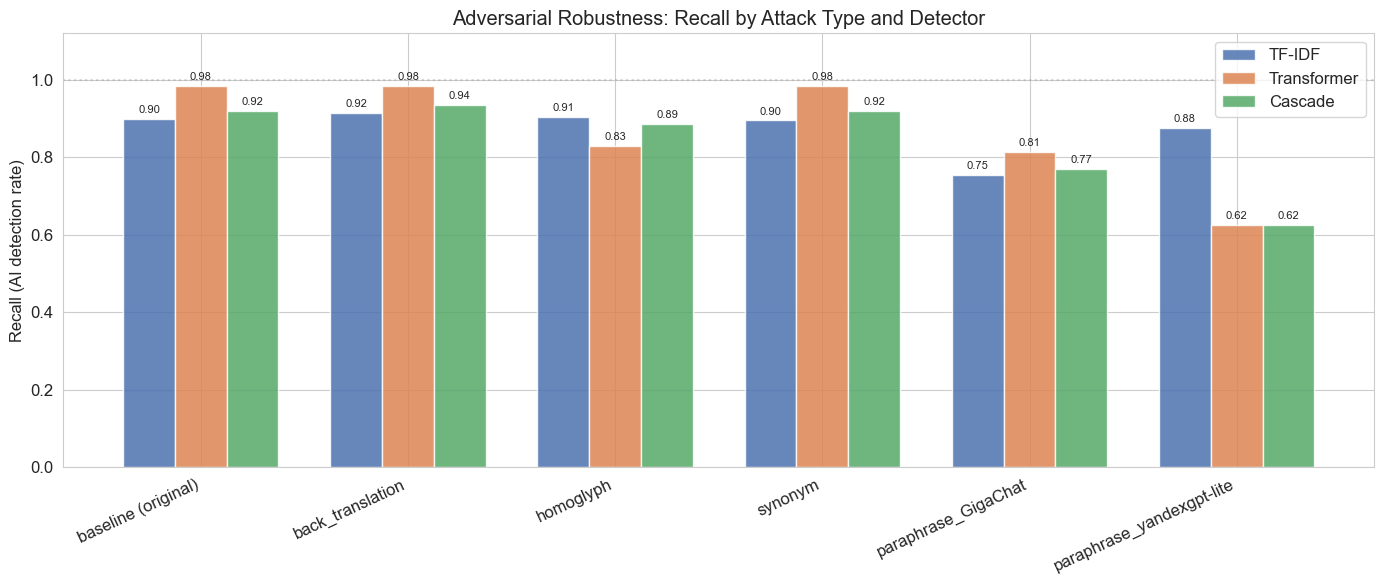

In [7]:
# Grouped bar chart: recall по атакам и детекторам
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(pivot_recall.index))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, (det, color) in enumerate(zip(pivot_recall.columns, colors)):
    bars = ax.bar(x + i * width, pivot_recall[det], width, label=det, color=color, alpha=0.85)
    for bar, val in zip(bars, pivot_recall[det]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Recall (AI detection rate)")
ax.set_title("Adversarial Robustness: Recall by Attack Type and Detector")
ax.set_xticks(x + width)
ax.set_xticklabels(pivot_recall.index, rotation=25, ha="right")
ax.legend()
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/adversarial_v2_recall.png"), dpi=150, bbox_inches="tight")
plt.show()

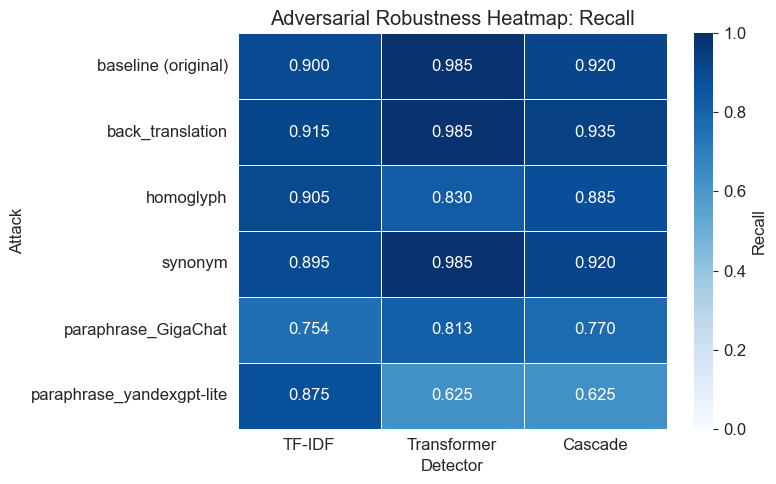

In [8]:
# Heatmap: recall
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_recall, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Recall"})
ax.set_title("Adversarial Robustness Heatmap: Recall")
ax.set_ylabel("Attack")
ax.set_xlabel("Detector")
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/adversarial_v2_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

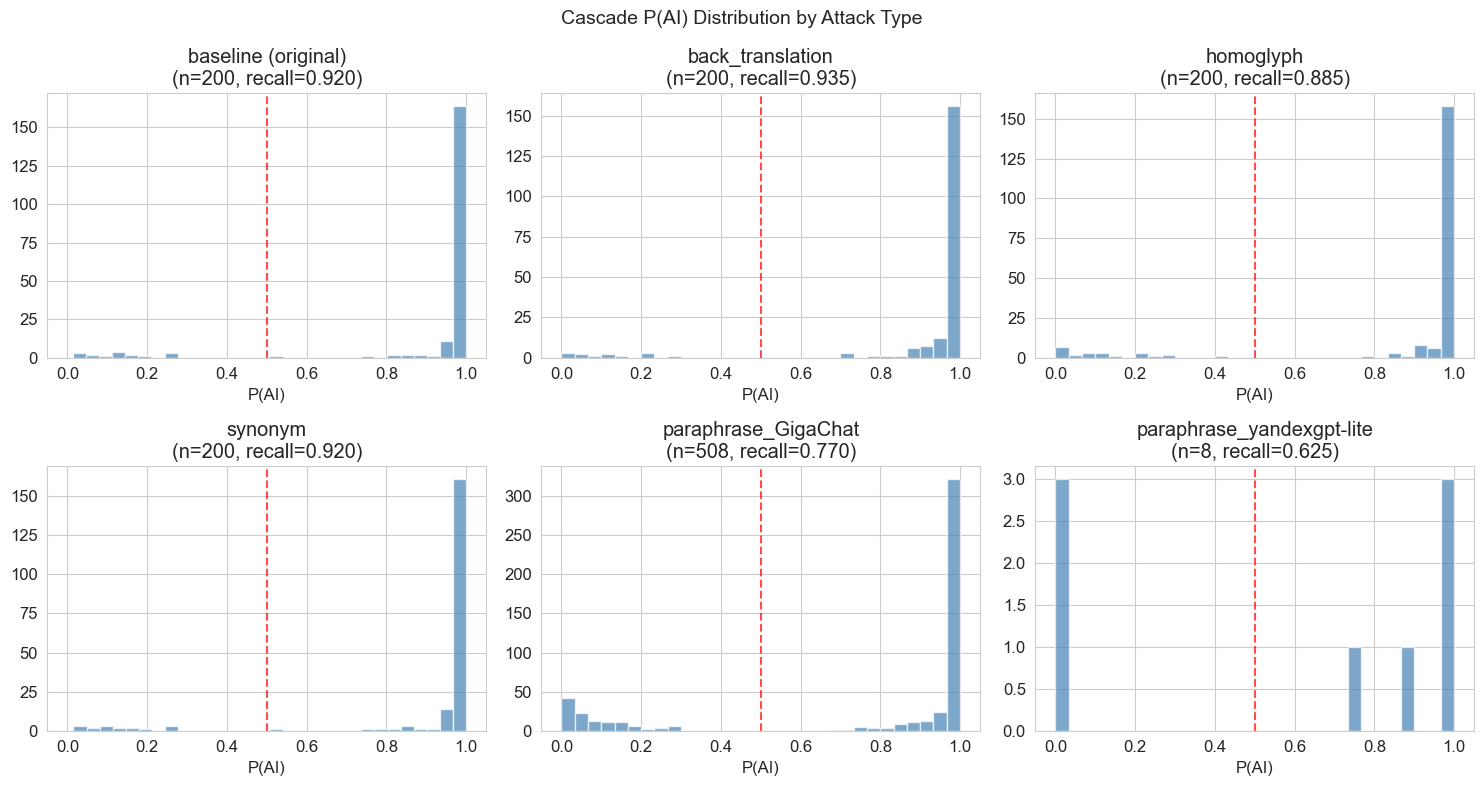

In [9]:
# Распределение P(AI) по атакам для Cascade
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (set_name, texts) in enumerate(eval_sets.items()):
    if i >= len(axes):
        break
    probs = cascade_predict_proba(texts)
    ax = axes[i]
    ax.hist(probs, bins=30, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.7)
    ax.set_title(f"{set_name}\n(n={len(texts)}, recall={recall_score(np.ones(len(texts)), (probs >= 0.5).astype(int)):.3f})")
    ax.set_xlabel("P(AI)")
    ax.set_xlim(-0.05, 1.05)

# Убрать лишние axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Cascade P(AI) Distribution by Attack Type", fontsize=14)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "artifacts/adversarial_v2_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Сохранение результатов

In [10]:
# Сохраняем таблицы
df_results.to_csv(PROJECT_ROOT / "artifacts/adversarial_v2_eval_raw.csv", index=False)
pivot_recall.to_csv(PROJECT_ROOT / "artifacts/adversarial_v2_recall_pivot.csv")
pivot_prob.to_csv(PROJECT_ROOT / "artifacts/adversarial_v2_prob_pivot.csv")

print("Saved:")
print("  artifacts/adversarial_v2_eval_raw.csv")
print("  artifacts/adversarial_v2_recall_pivot.csv")
print("  artifacts/adversarial_v2_prob_pivot.csv")
print("  artifacts/adversarial_v2_recall.png")
print("  artifacts/adversarial_v2_heatmap.png")
print("  artifacts/adversarial_v2_distributions.png")

Saved:
  artifacts/adversarial_v2_eval_raw.csv
  artifacts/adversarial_v2_recall_pivot.csv
  artifacts/adversarial_v2_prob_pivot.csv
  artifacts/adversarial_v2_recall.png
  artifacts/adversarial_v2_heatmap.png
  artifacts/adversarial_v2_distributions.png


## 7. Limitations & Future Work

### Cross-generator generalization (LOO)

В текущей работе обобщаемость на unseen-генераторы оценивается через **holdout_tm_unseen** (тексты Qwen2.5,
не представленного в обучающей выборке). Полный Leave-One-Out (LOO) по генераторам —
обучение N моделей, каждая без одного генератора, с оценкой на нём — не проводился.

**Почему это ограничение:**
- LOO даёт более строгую оценку cross-generator robustness
- Один unseen-генератор (Qwen) может быть нерепрезентативным

**Почему мы считаем текущий подход достаточным:**
- Holdout на Qwen2.5 (полностью unseen) показывает, что модель обобщается на новые генераторы
- Три генератора в обучении (GigaChat, YandexGPT, GPT-4o-mini) покрывают разные архитектуры и API
- LOO потребовал бы переобучения 3+ моделей, что выходит за рамки данной работы

**Future work:** провести полный LOO-эксперимент, добавить генераторы (Claude, Gemma, Llama).